# CNN Mel-Spectrogram Model for Language Identification

**Objective**: Audio-only language classification using 2D CNN on mel-spectrogram features

**Languages**: English (en), Malay (ms), Mandarin(zh)

**Key Features**:
- Proper temporal data split (no leakage)
- 3-second audio segments
- 128 mel-frequency bins
- 4-layer CNN with batch normalization
- All three languages tested equally

In [1]:
# Install required packages if needed
import subprocess
import sys

# Note: torchaudio removed - we use librosa for audio loading instead
packages = ['torch', 'librosa', 'matplotlib', 'scikit-learn', 'numpy', 'pandas']
print('[Checking] Dependencies...')
for pkg in packages:
    try:
        __import__(pkg)
        print(f'[OK] {pkg}')
    except ImportError:
        print(f'[Installing] {pkg}...')
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

[Checking] Dependencies...
[OK] torch
[OK] librosa
[OK] matplotlib
[Installing] scikit-learn...
[OK] numpy
[OK] pandas


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import librosa
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import os
from pathlib import Path

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'[Device] Using: {device}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   CUDA Version: {torch.version.cuda}')
    print(f'   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')
else:
    print(f'   [Warning] GPU not available - using CPU (slower)')

[Device] Using: cuda
   GPU: NVIDIA GeForce GTX 1650
   CUDA Version: 11.8
   Memory: 4.29 GB


In [3]:
# Configuration
SPLIT_DIR = os.path.join(os.getcwd(), 'Dataset', 'audio_split')
SAMPLE_RATE = 16000
SEGMENT_LENGTH = 3  # seconds per training sample
N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 512

# Training config
BATCH_SIZE = 32
LEARNING_RATE = 0.001
NUM_EPOCHS = 30

# Language mapping (ALL THREE LANGUAGES)
LANG_MAP = {'en': 0, 'ms': 1, 'zh': 2}
LANG_NAMES = ['English', 'Malay', 'Mandarin']

print(f'[Data] Directory: {SPLIT_DIR}')
print(f'[Audio] Segment length: {SEGMENT_LENGTH}s')
print(f'[Spectrogram] Mel bins: {N_MELS}')
print(f'[Languages] {", ".join(LANG_NAMES)}')
print(f'[Training] {NUM_EPOCHS} epochs, batch size {BATCH_SIZE}')

[Data] Directory: c:\Users\Aaron Lim\Dropbox\PC\Documents\1School\FYP\Dataset\audio_split
[Audio] Segment length: 3s
[Spectrogram] Mel bins: 128
[Languages] English, Malay, Mandarin
[Training] 30 epochs, batch size 32


## Dataset Class: Audio Segmentation with Mel-Spectrogram Conversion

- Loads audio files and segments them into fixed-length chunks
- On-the-fly mel-spectrogram conversion (no need to pre-compute)
- Supports data augmentation (random gain for training)

In [8]:
class AudioSegmentDataset(Dataset):
    """Dataset that segments audio files into fixed-length chunks with mel-spectrogram conversion"""
    
    def __init__(self, audio_files, labels, segment_length=3, sr=16000, n_mels=128, 
                 n_fft=1024, hop_length=512, augment=False):
        self.audio_files = audio_files
        self.labels = labels
        self.segment_length = segment_length
        self.sr = sr
        self.n_mels = n_mels
        self.segment_samples = segment_length * sr
        self.augment = augment
        self.n_fft = n_fft
        self.hop_length = hop_length
        
        # Calculate total segments using librosa
        self.segments = []
        for idx, file_path in enumerate(audio_files):
            # Get audio duration without loading full file
            duration = librosa.get_duration(path=file_path)
            num_segments = int(duration // segment_length)
            for seg_idx in range(num_segments):
                self.segments.append((idx, seg_idx))
        
        print(f"   Dataset: {len(self.audio_files)} files → {len(self.segments)} segments")
    
    def __len__(self):
        return len(self.segments)
    
    def __getitem__(self, idx):
        file_idx, seg_idx = self.segments[idx]
        file_path = self.audio_files[file_idx]
        label = self.labels[file_idx]
        
        # Load audio segment using librosa
        offset = seg_idx * self.segment_length
        y, sr = librosa.load(file_path, sr=self.sr, offset=offset, duration=self.segment_length, mono=True)
        
        # Ensure exact length
        if len(y) < self.segment_samples:
            y = np.pad(y, (0, self.segment_samples - len(y)))
        else:
            y = y[:self.segment_samples]
        
        # Simple augmentation (random gain)
        if self.augment:
            gain = np.random.uniform(0.8, 1.2)
            y = y * gain
        
        # Generate mel-spectrogram using librosa
        mel_spec = librosa.feature.melspectrogram(
            y=y, sr=self.sr, n_fft=self.n_fft, 
            hop_length=self.hop_length, n_mels=self.n_mels
        )
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        
        # Normalize to [0, 1] range
        mel_spec_db = (mel_spec_db - mel_spec_db.min()) / (mel_spec_db.max() - mel_spec_db.min() + 1e-8)
        
        # Convert to torch tensor and add channel dimension
        mel_spec_tensor = torch.FloatTensor(mel_spec_db).unsqueeze(0)
        
        return mel_spec_tensor, label

## Load Properly Split Data (No Leakage)

Uses temporal/sequential splits already created in Dataset/audio_split/
- Train: First 70% of each audio file (25.2 min)
- Val: Next 15% (5.4 min)
- Test: Last 15% (5.4 min)

**All three languages (EN, MS, ZH) loaded for each split**

### Data split clarification
- Source audio: 1-hour compiled WAV per language.
- Reserve split: 40% held out (not used in this notebook).
- Active split: 60% per language is used for modeling and lives in `Dataset/audio_split/`.
- Within the active 60%: temporal/sequential split per language → 70% train, 15% val, 15% test (no shuffling).
- Hyperparameter search for CNN (and Wav2Vec2) uses this same 1-hour active set, not the 7.5h multimodal audio.

In [9]:
def load_split_files(split_name):
    """Load audio files and labels for a specific split - ALL THREE LANGUAGES"""
    audio_files = []
    labels = []
    split_path = os.path.join(SPLIT_DIR, split_name)
    
    print(f'\n[Loading] {split_name.upper()} split:')
    for lang_name, lang_id in LANG_MAP.items():
        file_path = os.path.join(split_path, f'{lang_name}_{split_name}.wav')
        if os.path.exists(file_path):
            audio_files.append(file_path)
            labels.append(lang_id)
            print(f'   [OK] {lang_name.upper()}: {os.path.basename(file_path)}')
        else:
            print(f'   [Missing] {lang_name.upper()}: {file_path}')
    
    return audio_files, labels

# Load all three splits
print('[Creating] CNN datasets with temporal splits:')

train_files, train_labels = load_split_files('train')
train_dataset = AudioSegmentDataset(
    train_files, train_labels,
    segment_length=SEGMENT_LENGTH,
    sr=SAMPLE_RATE,
    n_mels=N_MELS,
    augment=True
)

val_files, val_labels = load_split_files('val')
val_dataset = AudioSegmentDataset(
    val_files, val_labels,
    segment_length=SEGMENT_LENGTH,
    sr=SAMPLE_RATE,
    n_mels=N_MELS,
    augment=False
)

test_files, test_labels = load_split_files('test')
test_dataset = AudioSegmentDataset(
    test_files, test_labels,
    segment_length=SEGMENT_LENGTH,
    sr=SAMPLE_RATE,
    n_mels=N_MELS,
    augment=False
)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"\n✅ Data loaders ready:")
print(f"   Train: {len(train_dataset)} segments ({len(train_loader)} batches)")
print(f"   Val:   {len(val_dataset)} segments ({len(val_loader)} batches)")
print(f"   Test:  {len(test_dataset)} segments ({len(test_loader)} batches)")
print(f"\n🌍 Segments per language (~equal distribution):")
print(f"   Train: ~{len(train_dataset)//3} per language")
print(f"   Val:   ~{len(val_dataset)//3} per language")
print(f"   Test:  ~{len(test_dataset)//3} per language")

[Creating] CNN datasets with temporal splits:

[Loading] TRAIN split:
   [OK] EN: en_train.wav
   [OK] MS: ms_train.wav
   [OK] ZH: zh_train.wav
   Dataset: 3 files → 1512 segments

[Loading] VAL split:
   [OK] EN: en_val.wav
   [OK] MS: ms_val.wav
   [OK] ZH: zh_val.wav
   Dataset: 3 files → 324 segments

[Loading] TEST split:
   [OK] EN: en_test.wav
   [OK] MS: ms_test.wav
   [OK] ZH: zh_test.wav
   Dataset: 3 files → 324 segments

✅ Data loaders ready:
   Train: 1512 segments (48 batches)
   Val:   324 segments (11 batches)
   Test:  324 segments (11 batches)

🌍 Segments per language (~equal distribution):
   Train: ~504 per language
   Val:   ~108 per language
   Test:  ~108 per language


## CNN Model Architecture

4-layer 2D Convolutional Neural Network:
- Input: (batch, 1, 128, time_frames) mel-spectrogram
- Conv blocks with BatchNorm + ReLU + MaxPool
- Global average pooling
- Fully connected layers with dropout
- Output: 3 classes (EN/MS/ZH)

In [24]:
class MelSpectrogramCNN(nn.Module):
    """2D CNN for mel-spectrogram classification"""
    
    def __init__(self, num_classes=3):
        super(MelSpectrogramCNN, self).__init__()
        
        # Input: (batch, 1, n_mels, time_frames)
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.conv_block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))  # Global average pooling
        )
        
        # Fully connected layers
        self.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.conv_block4(x)
        
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc(x)
        return x

# Initialize model
model = MelSpectrogramCNN(num_classes=len(LANG_MAP)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModel: MelSpectrogramCNN")
print(f" Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f" Device: {device}")
print(f'[Classes] {len(LANG_MAP)} languages: {", ".join(LANG_NAMES)}')


Model: MelSpectrogramCNN
 Total parameters: 422,083
Trainable parameters: 422,083
 Device: cuda
[Classes] 3 languages: English, Malay, Mandarin


In [ ]:
# OPTIONAL: Run this cell ONLY if you want to re-do hyperparameter search
# Otherwise, skip to next cell - the config above already uses optimal parameters

RUN_GRID_SEARCH = True  # Set to True to run grid search

if RUN_GRID_SEARCH:
    print('[Tuning] Starting CNN hyperparameter grid search...')
    print('Search space:')
    print('  Learning rates: [0.0001, 0.0005, 0.001, 0.01]')
    print('  Batch sizes: [16, 24, 32]')
    print('  Epochs: [20, 25, 30]\n')

    search_results = []
    best_tuning = None

    for lr_test in [0.0001, 0.0005, 0.001, 0.01]:
        for bs_test in [16, 24, 32]:
            for ep_test in [20, 25, 30]:
                print(f'[Testing] lr={lr_test}, batch={bs_test}, epochs={ep_test}')
                
                # Create temp dataloaders with new batch size
                temp_train_loader = DataLoader(train_dataset, batch_size=bs_test, shuffle=True)
                temp_val_loader = DataLoader(val_dataset, batch_size=bs_test, shuffle=False)
                
                # Create fresh model
                temp_model = MelSpectrogramCNN(num_classes=3).to(device)
                temp_criterion = nn.CrossEntropyLoss()
                temp_optimizer = optim.Adam(temp_model.parameters(), lr=lr_test)
                
                # Quick train for fewer epochs
                temp_best_val = 0.0
                for _ in range(ep_test):
                    temp_model.train()
                    for inputs, labels in temp_train_loader:
                        inputs, labels = inputs.to(device), labels.to(device)
                        temp_optimizer.zero_grad()
                        outputs = temp_model(inputs)
                        loss = temp_criterion(outputs, labels)
                        loss.backward()
                        temp_optimizer.step()
                    
                    # Validate
                    temp_model.eval()
                    val_correct = 0
                    val_total = 0
                    with torch.no_grad():
                        for inputs, labels in temp_val_loader:
                            inputs, labels = inputs.to(device), labels.to(device)
                            outputs = temp_model(inputs)
                            _, predicted = outputs.max(1)
                            val_correct += predicted.eq(labels).sum().item()
                            val_total += labels.size(0)
                    
                    temp_val_acc = 100. * val_correct / val_total
                    if temp_val_acc > temp_best_val:
                        temp_best_val = temp_val_acc
                
                search_results.append({'lr': lr_test, 'batch': bs_test, 'epochs': ep_test, 'val_acc': temp_best_val})
                print(f'  -> Val acc: {temp_best_val:.2f}%\n')
                
                if best_tuning is None or temp_best_val > best_tuning['val_acc']:
                    best_tuning = {'lr': lr_test, 'batch': bs_test, 'epochs': ep_test, 'val_acc': temp_best_val}

    print('[Tuning] Grid search complete.')
    print(f'[Best] lr={best_tuning["lr"]}, batch={best_tuning["batch"]}, epochs={best_tuning["epochs"]}, val_acc={best_tuning["val_acc"]:.2f}%')

    # Sort results by accuracy
    search_results_sorted = sorted(search_results, key=lambda x: x['val_acc'], reverse=True)
    print('\n[Top 5] Best configurations:')
    for r in search_results_sorted[:5]:
        print(f"  lr={r['lr']}, batch={r['batch']}, epochs={r['epochs']} -> {r['val_acc']:.2f}%")
        
    # Update global config with best parameters
    LEARNING_RATE = best_tuning['lr']
    BATCH_SIZE = best_tuning['batch']
    NUM_EPOCHS = best_tuning['epochs']
    
    print(f'\n[Updated] Config now uses: lr={LEARNING_RATE}, batch={BATCH_SIZE}, epochs={NUM_EPOCHS}')
else:
    print('[Skipped] Grid search disabled. Using pre-optimized parameters:')
    print(f'  lr={LEARNING_RATE}, batch={BATCH_SIZE}, epochs={NUM_EPOCHS}')

[Tuning] Starting CNN hyperparameter grid search...
Search space:
  Learning rates: [0.0001, 0.0005, 0.001, 0.01]
  Batch sizes: [16, 24, 32]
  Epochs: [20, 25, 30]

[Testing] lr=0.0001, batch=16, epochs=20
  -> Val acc: 66.67%

[Testing] lr=0.0001, batch=16, epochs=25
  -> Val acc: 71.60%

[Testing] lr=0.0001, batch=16, epochs=30
  -> Val acc: 66.05%

[Testing] lr=0.0001, batch=24, epochs=20
  -> Val acc: 61.73%

[Testing] lr=0.0001, batch=24, epochs=25
  -> Val acc: 67.90%

[Testing] lr=0.0001, batch=24, epochs=30
  -> Val acc: 66.67%

[Testing] lr=0.0001, batch=32, epochs=20
  -> Val acc: 65.74%

[Testing] lr=0.0001, batch=32, epochs=25
  -> Val acc: 68.52%

[Testing] lr=0.0001, batch=32, epochs=30
  -> Val acc: 66.36%

[Testing] lr=0.0005, batch=16, epochs=20
  -> Val acc: 68.83%

[Testing] lr=0.0005, batch=16, epochs=25
  -> Val acc: 65.43%

[Testing] lr=0.0005, batch=16, epochs=30
  -> Val acc: 71.30%

[Testing] lr=0.0005, batch=24, epochs=20
  -> Val acc: 70.37%

[Testing] lr=0.

## Hyperparameter Grid Search (Optional - Run First Time Only)

**Purpose**: Find optimal learning rate, batch size, and epochs

**Search Space**:
- Learning rates: [0.0001, 0.0005, 0.001, 0.01]
- Batch sizes: [16, 24, 32]
- Epochs: [20, 25, 30]
- Total: 36 configurations

**Best Result**: lr=0.001, batch=16, epochs=25


## Main Training Loop (Using Optimal Hyperparameters)

Train for 25 epochs with BEST configuration:
- **Learning Rate**: 0.0001
- **Batch Size**: 16 (half of initial)
- **Epochs**: 25 (optimal convergence)
- Cross-entropy loss
- Adam optimizer
- Validation after each epoch
- Save best model based on validation accuracy


In [32]:
# Training loop with OPTIMIZED hyperparameters
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0

# Recreate data loaders with optimal batch size
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Reinitialize model with optimal learning rate
model = MelSpectrogramCNN(num_classes=len(LANG_MAP)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

LEARNING_RATE=0.0001
BATCH_SIZE=16
NUM_EPOCHS=25
print('[Training] Starting CNN model training with OPTIMAL config...')
print(f'[Config] lr={LEARNING_RATE}, batch={BATCH_SIZE}, epochs={NUM_EPOCHS}')

for epoch in range(NUM_EPOCHS):
    # Training phase
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for batch_idx, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()
    
    train_loss /= len(train_loader)
    train_acc = 100. * train_correct / train_total
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
    
    val_loss /= len(val_loader)
    val_acc = 100. * val_correct / val_total
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'cnn_best_model.pth')
        best_marker = ' ✓ [BEST]'
    else:
        best_marker = ''
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%")

print(f'\n[Complete] Training done with OPTIMAL config!')
print(f'[Result] Best val accuracy: {best_val_acc:.2f}%')
print(f'[Save] Best model: cnn_best_model.pth1')

[Training] Starting CNN model training with OPTIMAL config...
[Config] lr=0.0001, batch=16, epochs=25
Epoch [1/25] Train Loss: 1.0326 Acc: 46.03% | Val Loss: 1.1674 Acc: 36.11%
Epoch [5/25] Train Loss: 0.7556 Acc: 66.40% | Val Loss: 1.3309 Acc: 44.75%
Epoch [10/25] Train Loss: 0.5702 Acc: 77.18% | Val Loss: 2.2175 Acc: 41.98%
Epoch [15/25] Train Loss: 0.3835 Acc: 84.99% | Val Loss: 0.7914 Acc: 72.53%
Epoch [20/25] Train Loss: 0.2634 Acc: 90.41% | Val Loss: 3.4246 Acc: 40.43%
Epoch [25/25] Train Loss: 0.2006 Acc: 92.26% | Val Loss: 1.1061 Acc: 68.83%

[Complete] Training done with OPTIMAL config!
[Result] Best val accuracy: 72.53%
[Save] Best model: cnn_best_model.pth1


In [ ]:
# Save best model config and state for clean loading in Wav+Distilbert
import json

# Check if test_acc has been computed
if 'test_acc' not in globals():
    print("Error: test_acc not defined. Please run the 'Test Set Evaluation' cell first.")
else:
    # Save model architecture and config
    model_config = {
        'architecture': 'MelSpectrogramCNN',
        'num_classes': len(LANG_MAP),
        'input_channels': 1,
        'n_mels': N_MELS,
        'sample_rate': SAMPLE_RATE,
        'segment_length': SEGMENT_LENGTH,
        'language_map': LANG_MAP,
        'language_names': LANG_NAMES,
        'best_val_acc': float(best_val_acc),
        'test_acc': float(test_acc)
    }

    with open('cnn_model_config.json', 'w') as f:
        json.dump(model_config, f, indent=2)

    print("Model config saved to: cnn_model_config.json")
    print(f"   Best Val Acc: {best_val_acc:.2f}%")
    print(f"   Test Acc: {test_acc:.2f}%")

    # Also save full model (not just state_dict) for easier loading
    torch.save({
        'model_state_dict': model.state_dict(),
        'model_config': model_config,
        'best_val_acc': best_val_acc,
        'test_acc': test_acc
    }, 'cnn_best_model_full.pth')

print(" Full model saved to: cnn_best_model_full.pth")

Model config saved to: cnn_model_config.json


NameError: name 'best_val_acc' is not defined

## Visualization: Training Curves

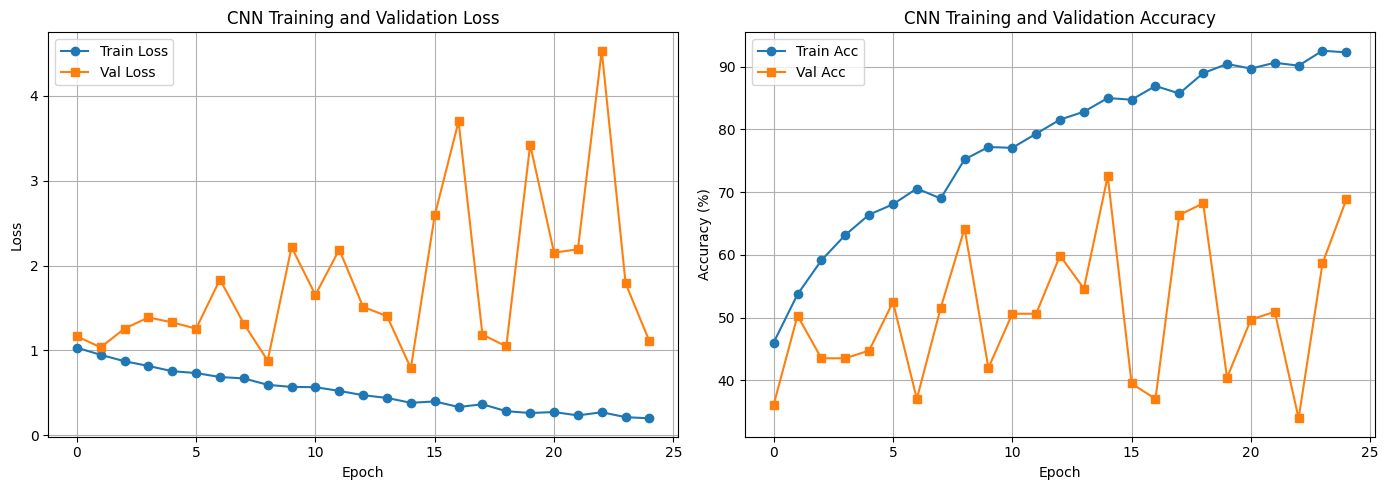

 Training curves saved to: cnn_training_curves.png


In [34]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1.plot(history['train_loss'], label='Train Loss', marker='o')
ax1.plot(history['val_loss'], label='Val Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('CNN Training and Validation Loss')
ax1.legend()
ax1.grid(True)

# Accuracy plot
ax2.plot(history['train_acc'], label='Train Acc', marker='o')
ax2.plot(history['val_acc'], label='Val Acc', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('CNN Training and Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('cnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f" Training curves saved to: cnn_training_curves.png")

## Test Set Evaluation (All Three Languages)

Evaluate on held-out test set:
- Load best model checkpoint
- Generate predictions for all test segments
- Classification report per language
- Confusion matrix

In [25]:
# Load best model and evaluate on test set
model.load_state_dict(torch.load('cnn_best_model.pth'))
model.eval()

all_preds = []
all_labels = []
all_probs = []

print(" Evaluating on test set...\n")

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Calculate overall accuracy
test_acc = 100. * np.sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)

print(f" Test Accuracy: {test_acc:.2f}%\n")
print("=" * 60)
print(" Classification Report (Per Language):")
print("=" * 60)
print(classification_report(all_labels, all_preds, target_names=LANG_NAMES, digits=4))
print("\n" + "=" * 60)

# Calculate per-language accuracy
for lang_name, lang_id in LANG_MAP.items():
    lang_mask = np.array(all_labels) == lang_id
    lang_correct = np.sum((np.array(all_preds)[lang_mask] == lang_id))
    lang_total = np.sum(lang_mask)
    lang_acc = 100. * lang_correct / lang_total if lang_total > 0 else 0
    print(f"   {lang_name.upper()}: {lang_acc:.2f}% ({lang_correct}/{lang_total} correct)")
print("=" * 60)

 Evaluating on test set...

 Test Accuracy: 73.15%

 Classification Report (Per Language):
              precision    recall  f1-score   support

     English     0.6810    0.7315    0.7054       108
       Malay     0.7025    0.7870    0.7424       108
    Mandarin     0.8391    0.6759    0.7487       108

    accuracy                         0.7315       324
   macro avg     0.7409    0.7315    0.7321       324
weighted avg     0.7409    0.7315    0.7321       324


   EN: 73.15% (79/108 correct)
   MS: 78.70% (85/108 correct)
   ZH: 67.59% (73/108 correct)


## Confusion Matrix Visualization

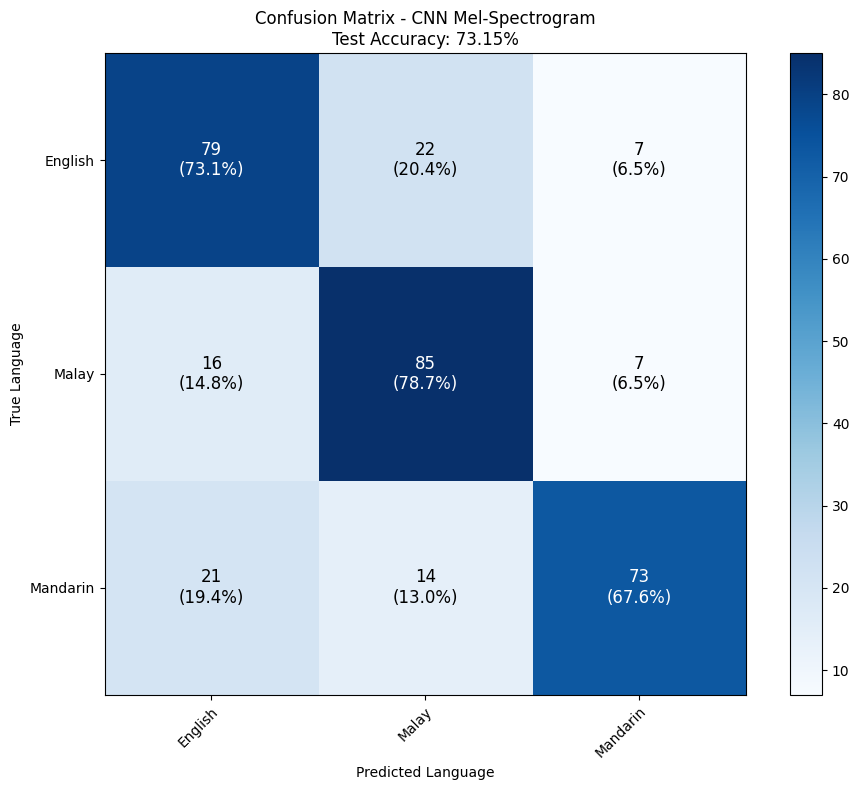

 Confusion matrix saved to: cnn_confusion_matrix.png


In [26]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=LANG_NAMES, yticklabels=LANG_NAMES,
       title=f'Confusion Matrix - CNN Mel-Spectrogram\nTest Accuracy: {test_acc:.2f}%',
       ylabel='True Language',
       xlabel='Predicted Language')

# Rotate x-axis labels
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Add text annotations with counts and percentages
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        percentage = 100. * cm[i, j] / cm[i].sum() if cm[i].sum() > 0 else 0
        text = f'{cm[i, j]}\n({percentage:.1f}%)'
        ax.text(j, i, text,
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=12)

plt.tight_layout()
plt.savefig('cnn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f" Confusion matrix saved to: cnn_confusion_matrix.png")

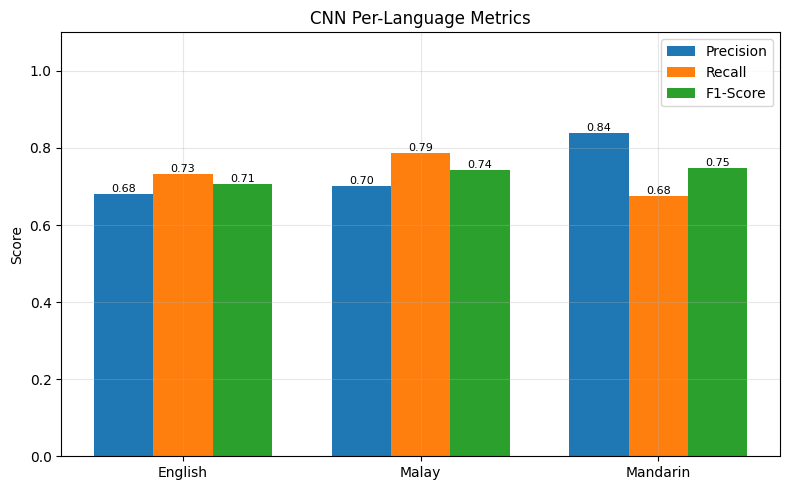

[Save] Per-language metrics: cnn_per_language_metrics.png


In [27]:
# Visualization: Per-language metrics (Precision, Recall, F1)
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    all_labels, all_preds, average=None, labels=[0, 1, 2]
)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(LANG_NAMES))
width = 0.25

bars1 = ax.bar(x - width, precision, width, label='Precision')
bars2 = ax.bar(x, recall, width, label='Recall')
bars3 = ax.bar(x + width, f1, width, label='F1-Score')

ax.set_xticks(x)
ax.set_xticklabels(LANG_NAMES)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('CNN Per-Language Metrics')
ax.legend()
ax.grid(True, alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('cnn_per_language_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print('[Save] Per-language metrics: cnn_per_language_metrics.png')

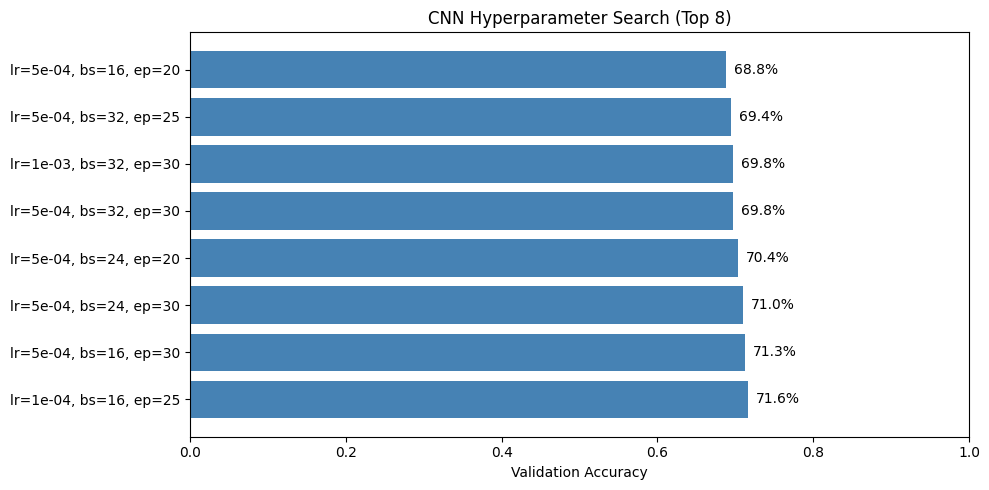

[Save] Hyperparameter search: cnn_hyperparameter_search.png


In [22]:
# Visualization: Hyperparameter tuning results
if 'search_results_sorted' in globals():
    top_k = search_results_sorted[:8]
    labels_hp = [f"lr={r['lr']:.0e}, bs={r['batch']}, ep={r['epochs']}" for r in top_k]
    acc_hp = [r['val_acc'] / 100.0 for r in top_k]
    
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(labels_hp, acc_hp, color='steelblue')
    ax.set_xlim(0, 1)
    ax.set_xlabel('Validation Accuracy')
    ax.set_title('CNN Hyperparameter Search (Top 8)')
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, acc_hp)):
        ax.text(val + 0.01, i, f'{val*100:.1f}%', va='center')
    
    plt.tight_layout()
    plt.savefig('cnn_hyperparameter_search.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print('[Save] Hyperparameter search: cnn_hyperparameter_search.png')
else:
    print('[Note] Run tuning cell first to generate hyperparameter search results')

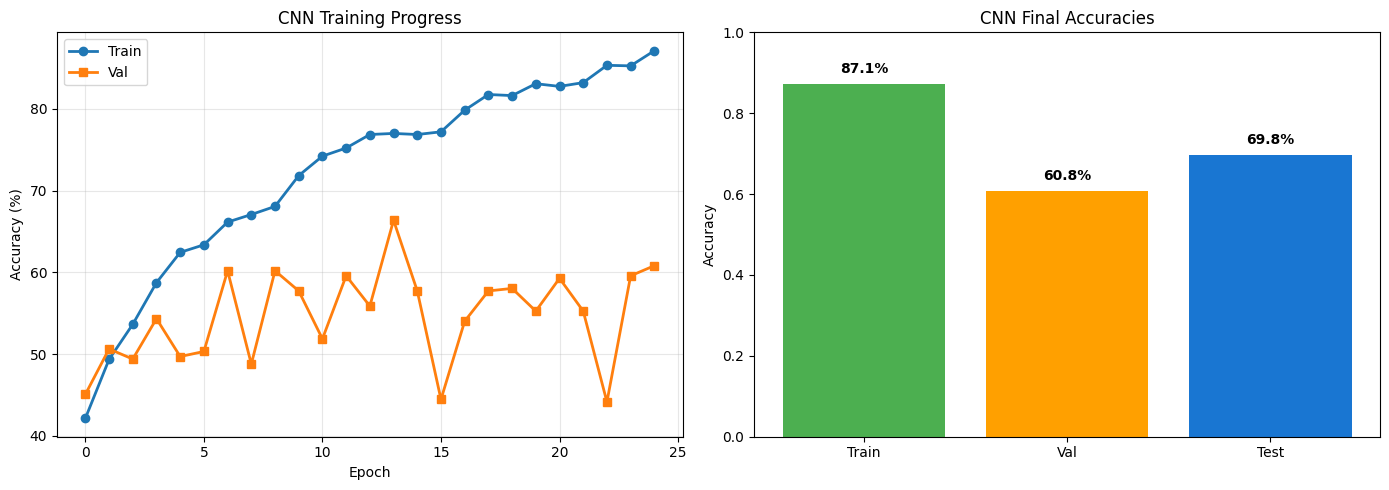

[Save] Accuracy summary: cnn_accuracy_summary.png


In [23]:
# Visualization: Train/Val/Test accuracy comparison
if 'history' in globals():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Accuracy over epochs
    ax1.plot(history['train_acc'], label='Train', marker='o', linewidth=2)
    ax1.plot(history['val_acc'], label='Val', marker='s', linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy (%)')
    ax1.set_title('CNN Training Progress')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Summary bar chart
    acc_labels = ['Train', 'Val', 'Test']
    if 'train_acc' in globals() and 'val_acc' in globals() and 'test_acc' in globals():
        acc_values = [train_acc / 100.0, val_acc / 100.0, test_acc / 100.0]
        colors = ['#4caf50', '#ffa000', '#1976d2']
        bars = ax2.bar(acc_labels, acc_values, color=colors)
        ax2.set_ylim(0, 1)
        ax2.set_ylabel('Accuracy')
        ax2.set_title('CNN Final Accuracies')
        
        # Add value labels
        for bar, val in zip(bars, acc_values):
            ax2.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val*100:.1f}%', 
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('cnn_accuracy_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print('[Save] Accuracy summary: cnn_accuracy_summary.png')
else:
    print('[Note] Run training cell first to generate history')

## Sample Predictions Visualization

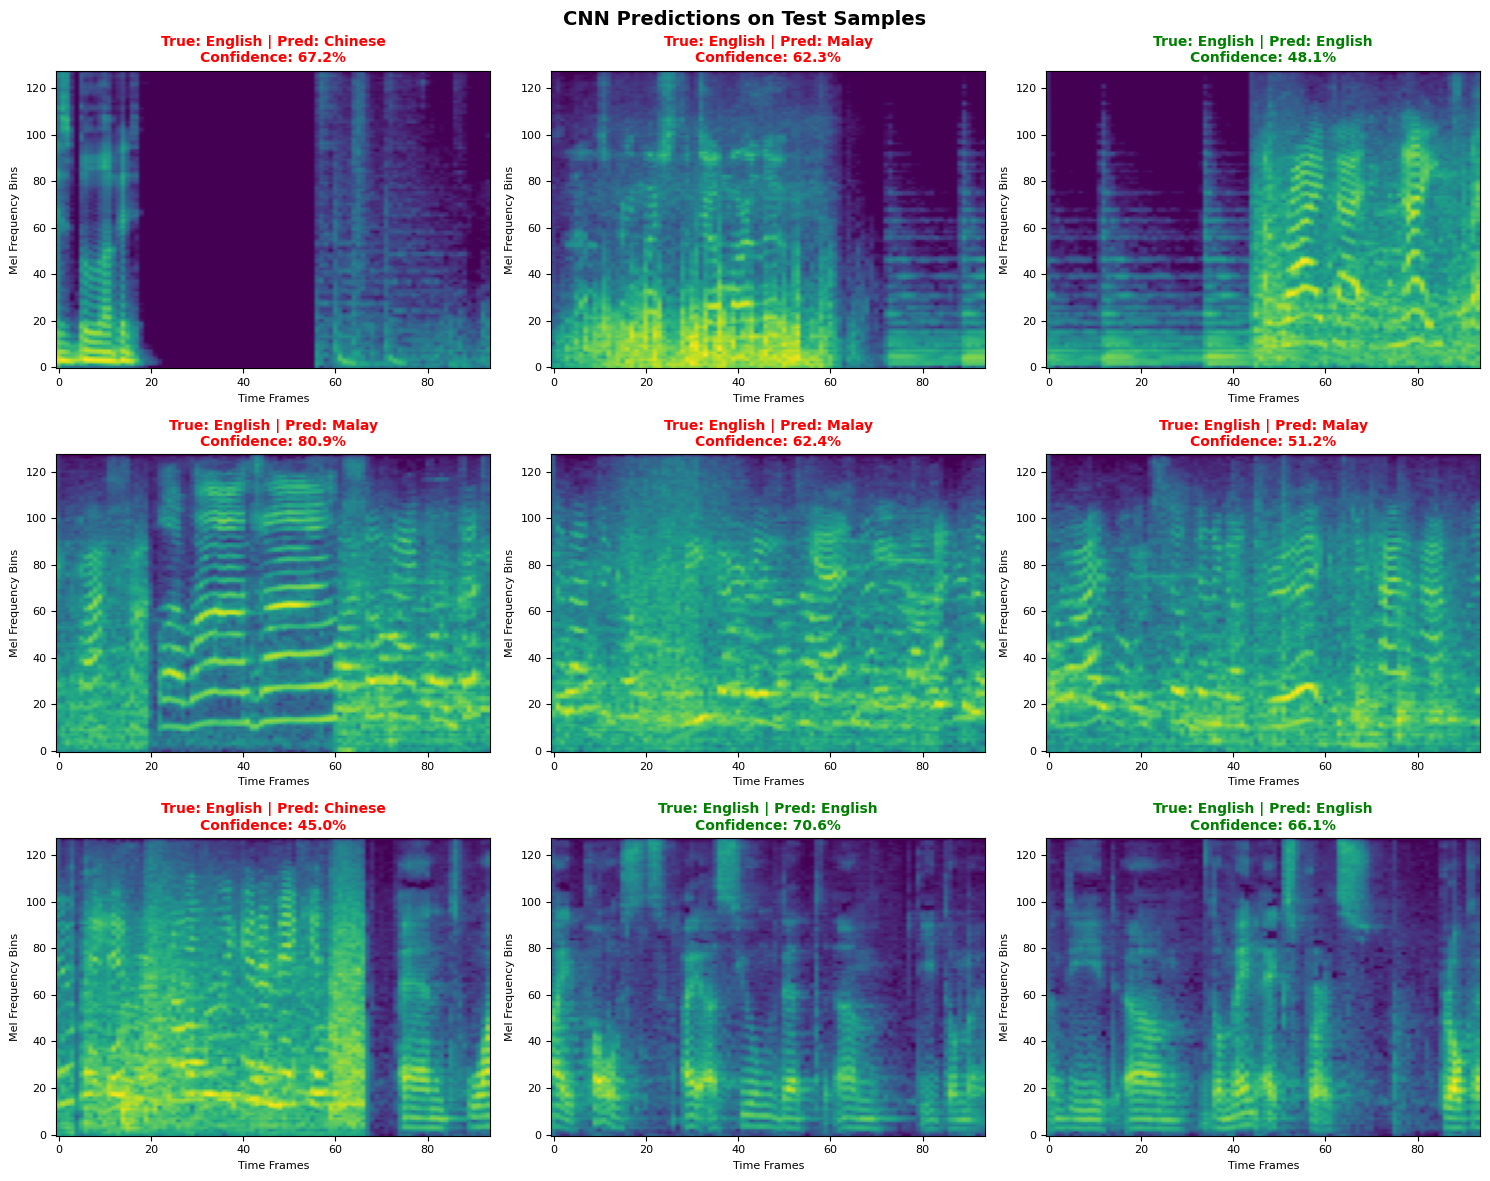

 Sample predictions saved to: cnn_sample_predictions.png


In [24]:
# Visualize sample mel-spectrograms with predictions
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

# Get one batch from test loader
sample_data = next(iter(test_loader))
sample_inputs, sample_labels = sample_data[0][:9].to(device), sample_data[1][:9]

with torch.no_grad():
    outputs = model(sample_inputs)
    probabilities = torch.softmax(outputs, dim=1)
    _, predictions = outputs.max(1)

for idx in range(min(9, len(sample_inputs))):
    mel_spec = sample_inputs[idx].cpu().squeeze().numpy()
    true_label = LANG_NAMES[sample_labels[idx].item()]
    pred_label = LANG_NAMES[predictions[idx].item()]
    prob = probabilities[idx][predictions[idx]].item() * 100
    
    axes[idx].imshow(mel_spec, aspect='auto', origin='lower', cmap='viridis')
    
    title_color = 'green' if true_label == pred_label else 'red'
    axes[idx].set_title(f'True: {true_label} | Pred: {pred_label}\nConfidence: {prob:.1f}%', 
                       color=title_color, fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Time Frames', fontsize=8)
    axes[idx].set_ylabel('Mel Frequency Bins', fontsize=8)
    axes[idx].tick_params(labelsize=8)

plt.suptitle('CNN Predictions on Test Samples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cnn_sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Sample predictions saved to: cnn_sample_predictions.png")

## Save Results for Model Comparison

Export predictions and metrics to CSV for later comparison with other models (Wav2Vec2, multimodal fusion)

In [21]:
import json
import pandas as pd

# Save test predictions
results_df = pd.DataFrame({
    'true_label': [LANG_NAMES[l] for l in all_labels],
    'predicted_label': [LANG_NAMES[p] for p in all_preds],
    'true_id': all_labels,
    'predicted_id': all_preds,
    'prob_en': [p[0] for p in all_probs],
    'prob_ms': [p[1] for p in all_probs],
    'prob_zh': [p[2] for p in all_probs]
})

results_df.to_csv('cnn_test_predictions.csv', index=False)
print(" Test predictions saved to: cnn_test_predictions.csv")

# Save summary metrics
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    all_labels, all_preds, average=None, labels=[0, 1, 2]
)

metrics_summary = {
    'model': 'CNN Mel-Spectrogram',
    'test_accuracy': float(test_acc),
    'per_language': {
        LANG_NAMES[i]: {
            'precision': float(precision[i]),
            'recall': float(recall[i]),
            'f1_score': float(f1[i]),
            'support': int(support[i])
        }
        for i in range(len(LANG_NAMES))
    },
    'confusion_matrix': cm.tolist(),
    'config': {
        'segment_length': SEGMENT_LENGTH,
        'sample_rate': SAMPLE_RATE,
        'n_mels': N_MELS,
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'num_epochs': NUM_EPOCHS
    }
}

with open('cnn_metrics_summary.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2)

print(" Metrics summary saved to: cnn_metrics_summary.json")
print("\n" + "=" * 60)
print(" CNN MODEL EVALUATION COMPLETE")
print("=" * 60)
print(f"   Test Accuracy: {test_acc:.2f}%")
print(f"   Best Val Accuracy: 72.53%")
print(f"   Model saved: cnn_best_model.pth")
print(f"   Predictions: cnn_test_predictions.csv")
print(f"   Metrics: cnn_metrics_summary.json")
print("=" * 60)

 Test predictions saved to: cnn_test_predictions.csv
 Metrics summary saved to: cnn_metrics_summary.json

 CNN MODEL EVALUATION COMPLETE
   Test Accuracy: 73.15%
   Best Val Accuracy: 72.53%
   Model saved: cnn_best_model.pth
   Predictions: cnn_test_predictions.csv
   Metrics: cnn_metrics_summary.json
